

## **Importing Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


## **Importing Datasets**

In [ ]:
# Datasets

files = [pd.read_csv(f"data/{file}", doublequote=False) for file in os.listdir("data") if file.endswith(".csv")]

main_df = pd.concat(files, ignore_index=True)

main_df.tail()


,Region,PHI,Barangay,Disease,No. of Cases,MW
17926,NIR,Negros Occidental,Talacagay,Typhoid,3.0,6
17927,NIR,Negros Occidental,Buluangan,Typhoid,3.0,6
17928,NIR,Negros Oriental,Buenavista,Typhoid,3.0,6
17929,NIR,Negros Oriental,Poblacion,Typhoid,4.0,6
17930,NIR,Negros Oriental,Old Namangka,Typhoid,3.0,6




## **Data Cleaning**

In [3]:
# General Cleaning

main_df = main_df.dropna()

In [ ]:
# Region (Roman Numerals or Acronyms)

main_df["Region"] = main_df["Region"].replace({3: "III",
                                          "4A": "IV-A",
                                          "REGION VI (WESTERN VISAYAS)": "VI",
                                          "MIMAROPA REGION": "IV-B",
                                          "REGION IV-A (CALABARZON)": "IV-A",
                                          "REGION IX (ZAMBOANGA PENINSULA)": "IX",
                                          "REGION VIII (EASTERN VISAYAS)": "VIII",
                                          "REGION III (CENTRAL LUZON)": "III",
                                          "NATIONAL CAPITAL REGION (NCR)": "NCR",
                                          "REGION XIII (CARAGA)": "XIII",
                                          "REGION II (CAGAYAN VALLEY)": "II",
                                          "REGION V (BICOL REGION)": "V",
                                          "REGION XII (SOCCSKSARGEN)": "XII",
                                          "NEGROS ISLAND REGION (NIR)": "NIR",
                                          "REGION XI (DAVAO REGION)": "XI",
                                          "5": "V",
                                          "11": "XI",
                                          "10": "X",
                                          "4B": "IV-B",
                                          "12": "XII",
                                          "9": "IX",
                                          "7": "VII",
                                          "6": "VI",
                                          "2": "II",
                                          "1": "I",
                                          "3": "III",
                                          "REGION VII (CENTRAL VISAYAS)": "VII",
                                          "8": "VIII",
                                          "REGION X (NORTHERN MINDANAO)": "X",
                                          "REGION I (ILOCOS REGION)": "I",
                                          "CORDILLERA ADMINISTRATIVE REGION (CAR)": "CAR",
                                          "BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO (BARMM)": "BARMM"})


In [5]:
# PHI
main_df["PHI"] = main_df["PHI"].str.upper()

main_df["PHI"] = main_df["PHI"].str.replace(r"CITY OF (.+)", r"\1 CITY", regex=True)
main_df["PHI"] = main_df["PHI"].str.replace(r"\(.*?\)", "", regex=True).str.strip()
main_df["PHI"] = main_df["PHI"].str.replace("Ã", "Ñ")
main_df["PHI"] = main_df["PHI"].str.replace("Ã±", "Ñ")
main_df.loc[main_df["PHI"] == "LAS PIÑAS", "PHI"] = main_df["PHI"] + " CITY"



In [6]:
# Barangay

main_df["Barangay"] = main_df["Barangay"].str.upper()
main_df["Barangay"] = main_df["Barangay"].str.replace(r"\(.*?\)", "", regex=True).str.strip()
main_df["Barangay"] = main_df["Barangay"].str.replace("BARANGAY", "BRGY.", regex=False)
main_df["Barangay"] = main_df["Barangay"].str.replace("BRGY", "BRGY.", regex=False)
main_df["Barangay"] = main_df["Barangay"].str.replace("Ã", "Ñ")
main_df["Barangay"] = main_df["Barangay"].str.replace("Ã±", "Ñ")
main_df["Barangay"] = main_df["Barangay"].str.replace("POB.", "", regex=False).str.strip()
main_df["Barangay"] = main_df["Barangay"].str.replace("R.A.PADILLA", "R.A. PADILLA")



In [7]:
# No. of Cases
main_df["No. of Cases"] = main_df["No. of Cases"].astype(int)

In [59]:
# Disease
main_df.loc[main_df["Disease"] == "Influenze-like Illness", "Disease"] = "Influenza-like Illness (ILI)"



## **EDA Summary**

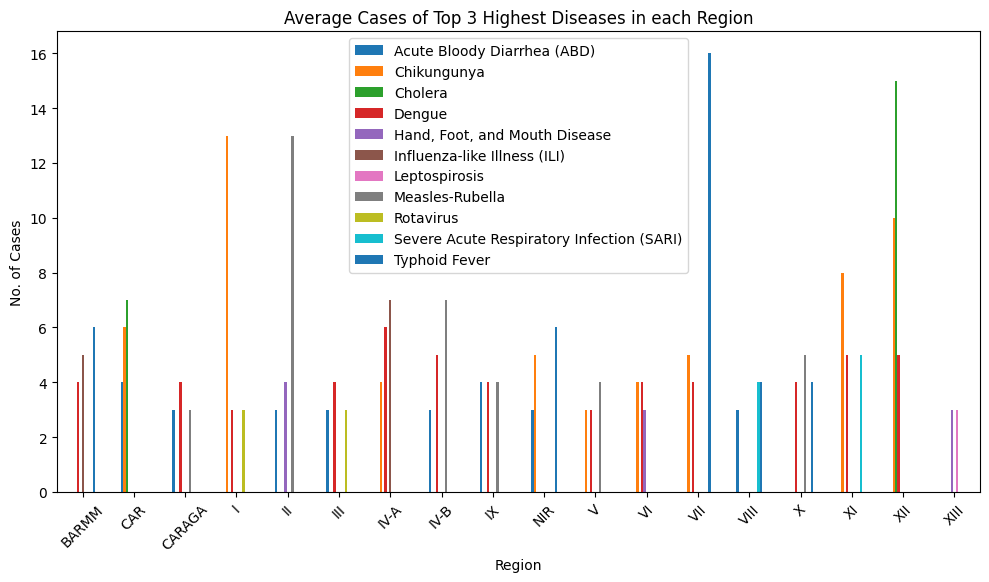

In [ ]:
# Plot cluster chart

reg_disease = main_df.groupby(['Region', 'Disease'])["No. of Cases"].mean().reset_index()

reg_disease = reg_disease[reg_disease['Region'] != 'NCR']

reg_disease['No. of Cases'] = reg_disease['No. of Cases'].astype('int')

reg_disease['rank'] = reg_disease.groupby('Region')['No. of Cases'].rank(method="first", ascending=False)

top_per_reg = reg_disease[reg_disease['rank'] <= 3]

pivoted = top_per_reg.pivot(index='Region', columns='Disease', values='No. of Cases').fillna(0)

pivoted = pivoted.loc[:, (pivoted != 0).any()]

fig, ax = plt.subplots(figsize=(10, 6))

pivoted.plot(kind="bar", ax=ax)

ax.set_xlabel('Region')
ax.set_ylabel('No. of Cases')
ax.set_title('Average Cases of Top 3 Highest Diseases in each Region')
ax.legend(loc='upper center')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


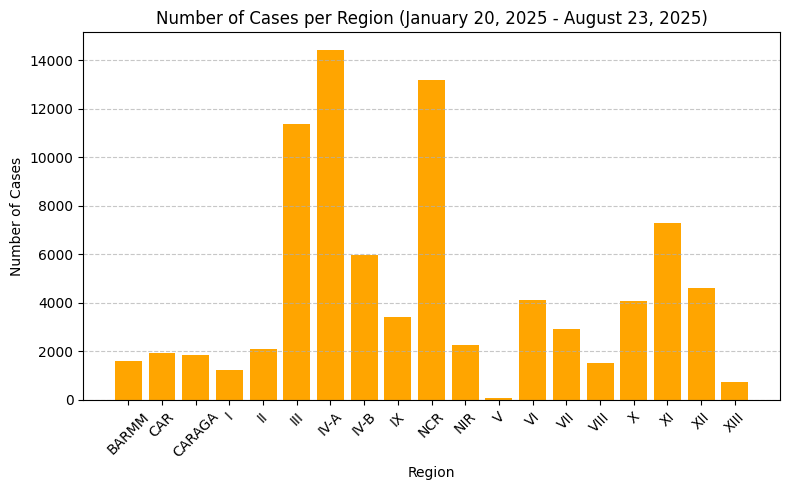

In [64]:
# Plot bar chart
cases_per_region = main_df.groupby('Region')["No. of Cases"].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(cases_per_region["Region"], cases_per_region["No. of Cases"], color="orange")

plt.title("Number of Cases per Region (January 20, 2025 - August 23, 2025)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.ylabel("Number of Cases")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()